# 01. Virtual File System - Context Offloading

이 노트북에서는 Deep Agents의 핵심 기능인 **Virtual File System**을 통한 **Context Offloading**을 학습합니다.

## 학습 목표

- **Context 관리의 필요성**: 복잡한 작업(50+ tool calls)에서 컨텍스트가 급격히 증가하는 문제
- **Context Offloading**: 파일 시스템을 활용한 컨텍스트 관리 전략
- **Virtual File System**: LangGraph State 내에서 파일 시스템 구현
- **File Tools**: `ls()`, `read_file()`, `write_file()` 도구 구현 및 활용

## 왜 File System이 필요한가?

복잡한 에이전트 작업에서는:
- **평균 50회 이상의 tool calls** 발생 (예: Manus 시스템)
- 모든 tool call 결과가 context window에 누적
- Token 사용량 급증 → 비용 증가 & 성능 저하

**Solution: Context Offloading**
- 긴 내용을 파일로 저장
- 필요할 때만 파일에서 읽어옴
- Context window는 깨끗하게 유지

**실전 사례:**
- [Manus](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus): 웹 리서치 결과를 파일로 저장
- [Anthropic Multi-Agent System](https://www.anthropic.com/engineering/multi-agent-research-system): SubAgent 출력을 파일로 저장하여 "game of telephone" 방지
- [Hugging Face Open Deep Research](https://huggingface.co/blog/open-deep-research): 리서치 플랜을 파일로 저장하여 재사용

## 1. 환경 설정

In [203]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("API Key가 설정되었습니다.")

API Key가 설정되었습니다.


In [204]:
from typing import Annotated
from langchain.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState

from langchain.agents import create_agent
from langgraph.types import Command
from typing_extensions import NotRequired

## 2. Virtual File System 이해하기

### 핵심 개념

**Virtual File System**은 실제 파일 시스템이 아니라 **LangGraph State 안의 Dictionary**입니다:

```python
state = {
    "messages": [...],
    "files": {
        "research_plan.txt": "1. 리서치 주제 정하기\n2. 자료 수집\n...",
        "web_results.md": "# 검색 결과\n...",
    }
}
```

### 특징

✅ **Thread-wise Persistence**: 하나의 대화 세션 내에서 유지됨  
✅ **State Management**: LangGraph State로 관리되어 추적 가능  
✅ **Lightweight**: 별도 DB나 파일 시스템 불필요  
❌ **Cross-thread**: 다른 대화 세션과는 공유 안됨

## 3. State 정의 및 File Reducer

먼저 파일을 병합하는 reducer 함수를 정의하고, LangChain의 `AgentState`를 확장하여 `files` 필드를 추가합니다.

In [205]:
from langchain.agents import AgentState

def file_reducer(left, right):
    """두 파일 딕셔너리를 병합하며, right side가 우선합니다.

    Args:
        left: 기존 파일 딕셔너리
        right: 새로운/업데이트된 파일 딕셔너리

    Returns:
        병합된 딕셔너리 (right 값이 left 값을 덮어씀)
    """
    if left is None:
        return right
    elif right is None:
        return left
    else:
        return {**left, **right}

class DeepAgentState(AgentState):
    """Deep Agent를 위한 확장 상태 정의.

    LangChain의 AgentState를 상속받아 virtual file system을 추가합니다.

    Attributes:
        messages: 대화 메시지 리스트 (AgentState로부터 상속)
        files: Virtual file system - {파일경로: 내용} 딕셔너리
    """
    files: Annotated[NotRequired[dict[str, str]], file_reducer]

## 4. File Tools 구현

3가지 핵심 도구를 구현합니다:

1. **`ls()`**: 파일 목록 보기
2. **`read_file()`**: 파일 내용 읽기 (pagination 지원)
3. **`write_file()`**: 파일 쓰기

### 4.1. ls() - 파일 목록 조회

In [206]:
@tool
def ls(state: Annotated[DeepAgentState, InjectedState]) -> list[str]:
    """에이전트의 state에 저장된 가상 파일 시스템의 모든 파일을 나열합니다.

    에이전트 메모리에 현재 존재하는 파일을 보여줍니다. 다른 파일 작업을 수행하기 전에
    컨텍스트를 정리하고 파일 구조에 대한 인식을 유지하는 데 사용하십시오.

    매개변수가 필요하지 않습니다 - 단순히 ls()를 호출하여 사용 가능한 모든 파일을 확인하십시오.
    """
    return list(state.get("files", {}).keys())

### 4.2. read_file() - 파일 읽기 (Pagination 지원)

In [207]:
@tool
def read_file(
    file_path: str,
    state: Annotated[DeepAgentState, InjectedState],
    offset: int = 0,
    limit: int = 2000,
) -> str:
    """가상 파일 시스템의 파일 내용을 선택적 페이지네이션과 함께 읽습니다.

    이 도구는 파일 내용을 줄 번호와 함께 반환하며,
    큰 파일을 청크 단위로 읽어 컨텍스트 오버플로를 방지할 수 있습니다.

    Args:
        file_path: 읽고자 하는 파일의 경로
        offset: 읽기를 시작할 줄 번호 (기본값: 0)
        limit: 읽을 최대 줄 수 (기본값: 2000)

    Returns:
        줄 번호와 함께 포맷된 파일 내용

    사용 예시:
    - 파일 구조 파악: read_file("data.md", offset=0, limit=50)
    - 특정 섹션: read_file("data.md", offset=300, limit=200)  # 300-500줄
    - 순차 읽기: offset을 점진적으로 증가 (0 → 200 → 400 → ...)

    편집을 수행하기 전에 기존 내용을 이해하는 것이 필수적입니다.
    """
    files = state.get("files", {})

    # 파일 존재 여부 확인
    if file_path not in files:
        return f"오류: 파일 '{file_path}'을(를) 찾을 수 없습니다"

    content = files[file_path]
    if not content:
        return "시스템 알림: 파일은 존재하지만 내용이 비어 있습니다"

    # 줄 단위로 분리
    lines = content.splitlines()
    start_idx = offset
    end_idx = min(start_idx + limit, len(lines))

    # 범위 체크
    if start_idx >= len(lines):
        return f"오류: 줄 오프셋 {offset}이 파일 길이({len(lines)} 줄)를 초과합니다"

    # 라인 넘버와 함께 포맷팅
    result_lines = []
    for i in range(start_idx, end_idx):
        line_content = lines[i][:2000]  # 너무 긴 라인은 잘라냄
        result_lines.append(f"{i + 1:6d}\t{line_content}")

    return "\n".join(result_lines)

### 4.3. write_file() - 파일 쓰기

**중요**: `write_file()`은 State를 업데이트해야 하므로 `Command`를 반환합니다.

In [208]:
@tool
def write_file(
    file_path: str,
    content: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """가상 파일 시스템에서 새 파일을 생성하거나 기존 파일을 완전히 덮어씁니다.

    이 도구는 새 파일을 생성하거나 전체 파일 내용을 교체합니다. 초기 파일 생성
    또는 전체 재작성에 사용하십시오. 파일은 에이전트 상태에 지속적으로 저장됩니다.

    Args:
        file_path: 파일이 생성/업데이트될 경로
        content: 파일에 쓸 내용

    Returns:
        새로운 파일 내용으로 에이전트 상태를 업데이트하는 명령

    Best practices:
    - 설명적인 파일 이름 사용
    - 관련 정보를 별도의 파일로 구성
    - 완전하고 잘 형식화된 내용 작성
    """
    # 현재 파일 시스템 가져오기
    files = state.get("files", {}).copy()

    # 파일 추가/업데이트
    files[file_path] = content

    # Command로 State 업데이트
    return Command(
        update={
            "files": files,
            "messages": [
                ToolMessage(
                    f"[WRITE FILE] 파일 업데이트 완료: {file_path}",
                    tool_call_id=tool_call_id
                )
            ],
        }
    )

## 5. 실습: File System을 활용한 Research Agent

이제 File System을 활용하는 간단한 Research Agent를 만들어봅시다.

### Workflow:
1. **Orient**: `ls()`로 현재 파일 확인
2. **Save Request**: 사용자 요청을 파일로 저장 (`write_file`)
3. **Research**: 웹 검색 수행
4. **Save Results**: 검색 결과를 파일로 저장
5. **Read & Answer**: 저장된 파일을 읽고 답변 생성

### 5.1. Mock Web Search Tool

실습을 위해 가짜 웹 검색 도구를 만듭니다. (실제로는 Tavily 등을 사용)

In [210]:
# Mock 검색 결과 - 실제 웹 리서치를 시뮬레이션 (약 5000+ 토큰)
MOCK_SEARCH_RESULT = """# OpenAI API 완전 가이드 - 종합 검색 결과

## ========================================
## 소스 1: OpenAI 공식 문서 (platform.openai.com)
## ========================================

### 개요
OpenAI API는 GPT-4, GPT-4o, GPT-3.5-Turbo, DALL-E 3, Whisper, TTS, Embeddings 등
다양한 최첨단 AI 모델에 접근할 수 있는 RESTful API 인터페이스를 제공합니다.

### 주요 기능

#### 1. Chat Completions API
- **모델**: gpt-4o, gpt-4-turbo, gpt-4, gpt-3.5-turbo
- **용도**: 대화형 AI, 챗봇, Q&A 시스템, 컨텐츠 생성
- **특징**:
  - 멀티턴 대화 지원
  - System/User/Assistant 역할 구분
  - Streaming 응답 지원 (SSE)
  - JSON mode 지원
  - Function calling / Tool use

**예시 코드:**
```python
from openai import OpenAI
client = OpenAI()

response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Hello!"}
    ],
    temperature=0.7,
    max_tokens=1000
)
print(response.choices[0].message.content)
```

#### 2. Function Calling
- AI가 구조화된 출력을 생성하여 외부 함수/API 호출
- 최신 모델(gpt-4o, gpt-4-turbo)에서 parallel function calling 지원
- Tool choice 옵션: auto, required, none
- Strict mode: JSON Schema validation 강화

**Function 정의 예시:**
```python
tools = [
    {
        "type": "function",
        "function": {
            "name": "get_weather",
            "description": "Get current weather for a location",
            "parameters": {
                "type": "object",
                "properties": {
                    "location": {"type": "string"},
                    "unit": {"type": "string", "enum": ["celsius", "fahrenheit"]}
                },
                "required": ["location"]
            }
        }
    }
]

response = client.chat.completions.create(
    model="gpt-4o",
    messages=[{"role": "user", "content": "What's the weather in Seoul?"}],
    tools=tools,
    tool_choice="auto"
)
```

#### 3. Vision API (GPT-4V)
- gpt-4o, gpt-4-turbo, gpt-4-vision-preview 모델에서 지원
- 이미지 URL 또는 base64 인코딩 이미지 입력
- OCR, 이미지 설명, 객체 인식, 차트 분석 등

**예시:**
```python
response = client.chat.completions.create(
    model="gpt-4o",
    messages=[{
        "role": "user",
        "content": [
            {"type": "text", "text": "What's in this image?"},
            {"type": "image_url", "image_url": {"url": "https://..."}}
        ]
    }]
)
```

#### 4. Embeddings
- 텍스트를 고차원 벡터로 변환
- 모델: text-embedding-3-large, text-embedding-3-small, text-embedding-ada-002
- 용도: 시맨틱 검색, 추천 시스템, 클러스터링, 이상 탐지

**차원 축소 지원:**
```python
embedding = client.embeddings.create(
    model="text-embedding-3-large",
    input="Your text here",
    dimensions=256  # 1536 → 256으로 축소 가능
)
```

#### 5. Image Generation (DALL-E 3)
- 텍스트 프롬프트에서 이미지 생성
- 해상도: 1024x1024, 1024x1792, 1792x1024
- 품질: standard, hd
- 스타일: natural, vivid

#### 6. Audio APIs
**Whisper (Speech-to-Text):**
- 음성 파일을 텍스트로 변환
- 다국어 지원 (99개 언어)
- Transcription & Translation

**TTS (Text-to-Speech):**
- 텍스트를 자연스러운 음성으로 변환
- 6가지 voice 옵션: alloy, echo, fable, onyx, nova, shimmer
- 모델: tts-1 (빠름), tts-1-hd (고품질)

#### 7. Moderation API
- 텍스트 컨텐츠 안전성 검사
- 카테고리: hate, harassment, self-harm, sexual, violence
- 무료 제공

## ========================================
## 소스 2: OpenAI 가격 정책 (2024년 기준)
## ========================================

### Chat Completions 가격

| 모델 | Input (1M tokens) | Output (1M tokens) | Context Window |
|------|-------------------|-------------------|----------------|
| **gpt-4o** | $2.50 | $10.00 | 128K |
| **gpt-4o-mini** | $0.150 | $0.600 | 128K |
| **gpt-4-turbo** | $10.00 | $30.00 | 128K |
| **gpt-4** | $30.00 | $60.00 | 8K |
| **gpt-4-32k** | $60.00 | $120.00 | 32K |
| **gpt-3.5-turbo** | $0.50 | $1.50 | 16K |

**Vision 기능 추가 비용:**
- 이미지 입력 시 토큰으로 계산
- 1024x1024 이미지 ≈ 765 tokens
- 저해상도 모드: 85 tokens/image

### Embeddings 가격

| 모델 | 가격 (1M tokens) | 차원 |
|------|-----------------|------|
| text-embedding-3-large | $0.13 | 3072 (축소 가능) |
| text-embedding-3-small | $0.02 | 1536 (축소 가능) |
| text-embedding-ada-002 | $0.10 | 1536 |

### Image Generation 가격

**DALL-E 3:**
- Standard 1024x1024: $0.040/image
- Standard 1024x1792/1792x1024: $0.080/image
- HD 1024x1024: $0.080/image
- HD 1024x1792/1792x1024: $0.120/image

**DALL-E 2:**
- 1024x1024: $0.020/image
- 512x512: $0.018/image
- 256x256: $0.016/image

### Audio 가격

**Whisper:**
- $0.006 / minute (전사 및 번역)

**TTS:**
- tts-1: $15.00 / 1M characters
- tts-1-hd: $30.00 / 1M characters

### Fine-tuning 가격

**GPT-3.5-turbo:**
- Training: $8.00 / 1M tokens
- Input: $3.00 / 1M tokens
- Output: $6.00 / 1M tokens

**GPT-4o-mini:**
- Training: $3.00 / 1M tokens
- Input: $0.300 / 1M tokens
- Output: $1.200 / 1M tokens

## ========================================
## 소스 3: Rate Limits & Quota (Tier 시스템)
## ========================================

### Usage Tier 구조

OpenAI는 5단계 tier 시스템을 운영:

#### Tier 1 (Free Trial)
- 자격: 새로운 계정 ($5 무료 크레딧)
- 기간: 첫 API 사용 후 3개월
- Rate Limit: 낮음
- Batch Queue: 제한적

#### Tier 2
- 자격: $5 이상 결제 + 7일 경과
- TPM (Tokens Per Minute):
  - gpt-4o: 450K TPM
  - gpt-4o-mini: 2M TPM
- RPM (Requests Per Minute): 500 RPM
- Batch Queue: 90K tokens/day

#### Tier 3
- 자격: $50 이상 결제 + 7일 경과
- TPM:
  - gpt-4o: 5M TPM
  - gpt-4o-mini: 10M TPM
- RPM: 5,000 RPM
- Batch Queue: 1.35M tokens/day

#### Tier 4
- 자격: $100 이상 결제 + 14일 경과
- TPM:
  - gpt-4o: 10M TPM
  - gpt-4o-mini: 30M TPM
- RPM: 10,000 RPM

#### Tier 5 (Enterprise)
- 자격: $1,000 이상 결제 + 30일 경과
- 대폭 증가한 한도
- 전담 지원팀

### Rate Limit 관리 팁
1. Exponential backoff 구현
2. Batch API 활용 (50% 할인)
3. 토큰 사용량 모니터링
4. Streaming으로 체감 속도 개선
5. 캐싱 전략 적용

## ========================================
## 소스 4: Best Practices & Design Patterns
## ========================================

### 1. Token 최적화
- 프롬프트 압축: 불필요한 단어 제거
- Temperature 조정: 창의성 vs 일관성 trade-off
- max_tokens 설정: 예산 통제
- Caching: 동일한 요청 재사용

### 2. 에러 처리
```python
from openai import OpenAI, RateLimitError, APIError
import time

def call_with_retry(client, max_retries=3):
    for attempt in range(max_retries):
        try:
            return client.chat.completions.create(...)
        except RateLimitError:
            wait_time = 2 ** attempt
            time.sleep(wait_time)
        except APIError as e:
            print(f"API Error: {e}")
            raise
    raise Exception("Max retries exceeded")
```

### 3. Prompt Engineering
- **Few-shot Learning**: 예시 제공
- **Chain-of-Thought**: 단계별 추론 유도
- **Role Prompting**: "You are an expert..."
- **Format Instructions**: 출력 형식 명시
- **Negative Prompting**: 하지 말아야 할 것 명시

### 4. 보안
- API 키 노출 방지 (.env 파일 사용)
- User ID 기반 사용량 추적
- Input validation & sanitization
- Moderation API 활용
- Rate limiting 구현

### 5. Production Deployment
- Load balancing across multiple keys
- Monitoring & alerting (token usage, latency, errors)
- Fallback strategies (모델 downgrade)
- Cost tracking per user/feature
- A/B testing for prompt optimization

## ========================================
## 소스 5: 제한사항 및 알려진 이슈
## ========================================

### Context Window 제한
- GPT-4o: 128K tokens
- 실제 효과적인 컨텍스트는 더 작을 수 있음 ("Lost in the middle" 현상)
- 긴 컨텍스트는 비용 증가 및 latency 증가

### Output Token 제한
- gpt-4o: max 16K output tokens
- gpt-4o-mini: max 16K output tokens
- 제한 초과 시 잘림 발생

### Rate Limits
- Tier별로 엄격히 제한
- Burst limits도 존재
- 429 에러 발생 시 backoff 필요

### 일관성 문제
- Temperature > 0일 때 비결정적 출력
- 동일 프롬프트에도 다른 응답 가능
- seed 파라미터로 일부 완화 가능 (베타)

### Hallucination
- 사실이 아닌 정보를 자신있게 생성
- 최신 정보 부족 (training cutoff)
- RAG, function calling으로 완화

### 다국어 성능 차이
- 영어가 가장 우수
- 한국어 등 비영어권은 성능 저하 가능
- 코드 스위칭 시 일관성 저하

## ========================================
## 소스 6: 실제 사용 사례 및 패턴
## ========================================

### Use Case 1: 고객 지원 챗봇
```python
# Context 저장 및 관리
conversation_history = []

def chat_with_memory(user_input):
    conversation_history.append({"role": "user", "content": user_input})

    response = client.chat.completions.create(
        model="gpt-4o-mini",  # 비용 효율적
        messages=[
            {"role": "system", "content": "You are a customer support agent..."},
            *conversation_history
        ],
        temperature=0.3  # 일관성 중시
    )

    assistant_message = response.choices[0].message.content
    conversation_history.append({"role": "assistant", "content": assistant_message})

    return assistant_message
```

### Use Case 2: RAG (Retrieval-Augmented Generation)
```python
# 벡터 DB에서 관련 문서 검색 후 컨텍스트로 제공
def rag_query(question, vector_db):
    # 1. Embedding 생성
    question_embedding = client.embeddings.create(
        model="text-embedding-3-small",
        input=question
    ).data[0].embedding

    # 2. 유사 문서 검색
    relevant_docs = vector_db.search(question_embedding, top_k=3)

    # 3. 컨텍스트와 함께 질문
    context = "\n\n".join([doc.content for doc in relevant_docs])

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[{
            "role": "user",
            "content": f"Context:\n{context}\n\nQuestion: {question}"
        }]
    )

    return response.choices[0].message.content
```

### Use Case 3: 코드 생성 및 분석
- 자연어 → 코드 변환
- 코드 리뷰 자동화
- 버그 탐지 및 수정 제안
- 문서화 자동 생성

### Use Case 4: 컨텐츠 생성
- 블로그 글 작성
- 소셜 미디어 포스트
- 광고 카피
- SEO 최적화 컨텐츠

## ========================================
## 소스 7: 경쟁사 비교
## ========================================

### OpenAI vs Anthropic Claude
- Claude 3.5 Sonnet: 200K context, 더 긴 출력 가능
- Claude는 Constitutional AI 적용 (안전성)
- OpenAI는 멀티모달(vision, audio) 더 강력
- 가격: Claude가 일부 모델에서 더 저렴

### OpenAI vs Google Gemini
- Gemini 1.5 Pro: 최대 2M context window
- Gemini는 무료 tier가 관대함
- OpenAI는 생태계 및 도구가 더 성숙
- Function calling 품질: OpenAI 우세

### OpenAI vs Open Source (Llama, Mistral)
- 오픈소스: 프라이버시, 커스터마이징 자유
- OpenAI: 성능, 편의성, 최신 기능
- 비용: 대량 사용 시 오픈소스가 유리
- 운영: OpenAI가 관리 부담 적음

## ========================================
## 결론 및 권장사항
## ========================================

### OpenAI API 선택 기준
✅ **다음 경우에 추천:**
- 빠른 프로토타이핑이 필요한 경우
- 최신 AI 기능(vision, voice)이 필요한 경우
- 개발 리소스가 제한적인 경우
- 높은 품질의 출력이 중요한 경우

⚠️ **주의가 필요한 경우:**
- 초대규모 트래픽 (비용 급증)
- 민감한 데이터 처리 (프라이버시)
- 오프라인 환경 필요
- 완전한 통제가 필요한 경우

### 비용 최적화 전략
1. gpt-4o-mini로 시작 → 필요시에만 gpt-4o 사용
2. Prompt caching 적용
3. Batch API 활용 (비실시간 작업)
4. Output token 제한 설정
5. Streaming으로 조기 종료

### 2024년 트렌드
- **Multimodal 확대**: 이미지, 음성, 비디오 통합
- **긴 컨텍스트**: 128K → 1M+ 예상
- **Custom Models**: Fine-tuning 접근성 향상
- **Agentic AI**: Function calling 고도화
- **Cost 감소**: 모델 효율성 개선

이 가이드는 2024년 4월 기준으로 작성되었으며, OpenAI는 지속적으로 업데이트됩니다.
최신 정보는 https://platform.openai.com/docs 참조.
"""

@tool
def web_search(query: str) -> str:
    """특정 주제에 대한 정보를 웹에서 검색합니다.

    이 도구는 웹 검색을 수행하고 주어진 쿼리에 대한 관련 결과를 반환합니다.
    인터넷에서 특정 주제에 대한 정보를 수집해야 할 때 사용하세요.

    ⚠️ **중요**: 이 도구의 결과는 매우 클 수 있습니다 (5000+ 문자).

    **반드시 다음 단계를 따르세요:**
    1. 이 도구를 호출하여 검색 결과를 받습니다
    2. 결과를 **완전히 그대로** write_file 도구로 저장합니다
       - 절대 요약하거나 생략하지 마세요
       - 전체 내용을 100% 그대로 파일에 저장하세요
    3. 파일을 읽고 사용자에게 답변합니다

    Args:
        query: 검색 쿼리 문자열.

    Returns:
        검색 결과 문자열 (매우 클 수 있음 - 반드시 파일로 저장하세요!)
    """
    print(f"🔍 웹 검색: {query}")
    return MOCK_SEARCH_RESULT

### 5.2. Agent 지시사항 (System Prompt)

### 5.3. 검증 헬퍼 함수

FilesystemMiddleware의 개념을 차용하여 파일에 저장된 내용이 원본인지 검증하는 함수를 만듭니다.

In [224]:
def verify_file_content(state: dict, expected_content: str, file_path: str) -> dict:
    """파일에 저장된 내용이 원본과 일치하는지 검증합니다.

    FilesystemMiddleware의 eviction 검증 로직을 차용한 헬퍼 함수입니다.

    Args:
        state: Agent 실행 결과 state
        expected_content: 예상되는 원본 내용
        file_path: 검증할 파일 경로

    Returns:
        검증 결과를 담은 딕셔너리
    """
    files = state.get("files", {})

    result = {
        "file_exists": file_path in files,
        "expected_size": len(expected_content),
        "expected_lines": len(expected_content.splitlines()),
    }

    if not result["file_exists"]:
        result["status"] = "❌ FAILED"
        result["reason"] = f"파일 '{file_path}'이(가) 존재하지 않습니다"
        return result

    actual_content = files[file_path]
    result["actual_size"] = len(actual_content)
    result["actual_lines"] = len(actual_content.splitlines())

    # 완전 일치 검사
    if actual_content == expected_content:
        result["status"] = "✅ PASSED"
        result["reason"] = "파일 내용이 원본과 100% 일치합니다"
        result["match_percentage"] = 100.0
    else:
        result["status"] = "⚠️  WARNING"

        # 부분 일치 비율 계산
        match_chars = sum(1 for a, b in zip(actual_content, expected_content) if a == b)
        result["match_percentage"] = (match_chars / len(expected_content)) * 100

    return result


def print_verification_report(verification: dict):
    """검증 결과를 보기 좋게 출력합니다."""
    print("\n" + "="*60)
    print("📋 파일 내용 검증 리포트")
    print("="*60)

    if verification['file_exists']:
        print(f"\n📊 크기 비교:")
        print(f"  예상: {verification['expected_size']:,} 문자 ({verification['expected_lines']} 줄)")
        print(f"  실제: {verification['actual_size']:,} 문자 ({verification['actual_lines']} 줄)")
        print(f"  일치율: {verification['match_percentage']:.1f}%")

    print("="*60)

In [212]:
SIMPLE_RESEARCH_INSTRUCTIONS = """당신은 사용자의 질문에 충실히 답변하는 어시스턴트입니다.

다음 규칙을 반드시 따르세요:

## 🚨 중요: 도구 결과 저장 규칙 (MANDATORY)

1. **web_search 결과는 무조건 파일로 저장**
   - web_search 도구를 호출한 직후, 그 결과를 반드시 write_file로 저장해야 합니다
   - 예외 없이 모든 웹 검색 결과를 파일로 저장하세요

2. **도구 결과는 절대 요약, 생략, 축약 금지**
   - write_file의 content 파라미터에는 도구 실행 결과를 **완전히 그대로** 전달하세요
   - 어떤 부분도 생략하거나 요약하지 마세요
   - "...생략..." 같은 표현 사용 금지
   - 도구가 반환한 원본 텍스트를 100% 그대로 저장하세요

3. **도구 실행 결과가 500자 이상이면 반드시 write_file로 저장**
   - 특히 웹 검색 결과, 긴 문서 내용 등
   - 파일 이름은 내용을 설명하는 명확한 이름 사용 (예: "openai_api_search_results.txt")

4. **절대 금지 사항**
   - 도구 실행 결과를 직접 사용자 응답에 포함하지 마세요
   - 긴 결과를 메시지 컨텍스트에 남기지 마세요
   - 파일로 저장하지 않고 요약만 제공하지 마세요

## 올바른 워크플로우:
1. web_search("쿼리") 호출
2. 결과 전체를 변수에 받음
3. 즉시 write_file("파일명.txt", **전체_결과_원본**) 호출
4. 파일을 참조하여 사용자에게 답변
"""

FILE_USAGE_INSTRUCTIONS = """다음은 컨텍스트 관리를 위한 지침입니다.

당신은 가상 파일 시스템에 접근할 수 있으며, 이를 통해 컨텍스트를 효율적으로 관리해야 합니다.
특히, 긴 도구 실행 결과의 경우 write_file로 컨텍스트를 저장하여 파일로 따로 관리하고, 추후에 read_file을 통해 필요한 부분을 읽어 활용합니다.

## Large Tool Results

도구 실행 결과가 매우 큰 경우, 다음과 같이 처리하세요:

1. **즉시 파일로 저장**
   - 큰 도구 결과는 즉시 write_file로 저장
   - 파일 경로: 설명적인 이름 사용 (예: "web_search_openai_api.txt")

2. **필요한 부분만 읽기**
   - 저장된 파일을 read_file로 읽되, pagination 사용
   - 처음부터 끝까지 다 읽지 말고 필요한 부분만 읽기

3. **파일 참조로 답변**
   - "파일 X에 저장된 내용을 보면..." 형태로 답변
   - 사용자가 더 필요하면 추가로 읽기

## Pagination Strategy

저장되어있는 큰 파일을 컨텍스트로 활용할 경우, 부분적으로 읽으세요.

read_file()은 offset과 limit 파라미터를 지원합니다:
- `offset`: 읽기 시작할 줄 번호 (0부터 시작)
- `limit`: 읽을 최대 줄 수 (기본값: 2000)

**사용 전략:**

1. **특정 정보만 필요한 경우**: 처음부터 모두 읽지 마세요!
   - 먼저 처음 일부만 읽어서 (offset=0, limit=50) 구조 파악
   - 질문에 필요한 섹션을 찾으면 해당 부분만 읽고 종료 가능

2. **전체 내용이 필요한 경우**: 순차적으로 읽기
   - read_file(offset=0, limit=200)    # 처음 200줄
   - read_file(offset=200, limit=200)  # 다음 200줄
   - 필요한 만큼만 계속
"""

# 전체 System Prompt
SYSTEM_PROMPT = (
    SIMPLE_RESEARCH_INSTRUCTIONS +
    "\n\n" + "=" * 80 + "\n\n" +
    FILE_USAGE_INSTRUCTIONS
)

In [213]:
SIMPLE_RESEARCH_INSTRUCTIONS = """당신은 사용자의 질문에 답변하는 어시스턴트입니다.

다음 규칙을 반드시 따르세요:

## 🚨 중요: 도구 결과 저장 규칙 (MANDATORY)

1. **web_search 결과는 무조건 파일로 저장**
   - web_search 도구를 호출한 직후, 그 결과를 반드시 write_file로 저장해야 합니다
   - 예외 없이 모든 웹 검색 결과를 파일로 저장하세요

2. **도구 결과는 절대 요약, 생략, 축약 금지**
   - write_file의 content 파라미터에는 도구 실행 결과를 **완전히 그대로** 전달하세요
   - 어떤 부분도 생략하거나 요약하지 마세요
   - "...생략..." 같은 표현 사용 금지
   - 도구가 반환한 원본 텍스트를 100% 그대로 저장하세요

3. **도구 실행 결과가 500자 이상이면 반드시 write_file로 저장**
   - 특히 웹 검색 결과, 긴 문서 내용 등
   - 파일 이름은 내용을 설명하는 명확한 이름 사용 (예: "openai_api_search_results.txt")

4. **절대 금지 사항**
   - 도구 실행 결과를 직접 사용자 응답에 포함하지 마세요
   - 긴 결과를 메시지 컨텍스트에 남기지 마세요
   - 파일로 저장하지 않고 요약만 제공하지 마세요

## 올바른 워크플로우:
1. web_search("쿼리") 호출
2. 결과 전체를 변수에 받음
3. 즉시 write_file("파일명.txt", **전체_결과_원본**) 호출
4. 파일을 참조하여 사용자에게 답변
"""


FILE_USAGE_INSTRUCTIONS = """컨텍스트 관리 규칙:

- 긴 정보는 직접 들고 있지 말고 파일로 저장 후 필요할 때 read_file로 읽으세요.
- 파일을 읽을 때는 항상 부분적으로 읽으세요 (pagination 사용).

Pagination:
- offset: 시작 줄
- limit: 최대 줄 수

전략:
1) 구조 파악 → read_file(offset=0, limit=50)
2) 필요한 부분만 추가로 읽기
"""

# 전체 System Prompt
SYSTEM_PROMPT = (
    SIMPLE_RESEARCH_INSTRUCTIONS +
    "\n\n" + "=" * 80 + "\n\n" +
    FILE_USAGE_INSTRUCTIONS
)

### 5.4. Agent 생성

In [214]:
tools = [ls, read_file, write_file, web_search]

# Agent 생성
agent = create_agent(
    model="gpt-4o",
    tools=tools,
    state_schema=DeepAgentState,
    system_prompt=SYSTEM_PROMPT,  # System prompt 주입
)

### 5.5. Agent 그래프 시각화

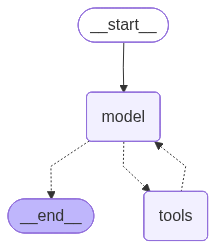

In [215]:
from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    pass

## 6. Agent 실행 및 결과 확인

이제 Agent를 실행하고 File System이 어떻게 작동하는지 확인해봅시다.

### 6.1. Agent 실행

In [216]:
# 초기 State: 빈 files dictionary
initial_state = {
    "messages": [
        {
            "role": "user",
            "content": "OpenAI API에 대해 알려주세요.",
        }
    ],
    "files": {},  # 빈 파일 시스템으로 시작
}

result = agent.invoke(initial_state)

🔍 웹 검색: OpenAI API


In [217]:
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

OpenAI API에 대해 알려주세요.
================================== Ai Message ==================================
Tool Calls:
  web_search (call_xG2l7N5ypCmSDc4vsfrGiqGK)
 Call ID: call_xG2l7N5ypCmSDc4vsfrGiqGK
  Args:
    query: OpenAI API
================================= Tool Message =================================
Name: web_search

# OpenAI API 완전 가이드 - 종합 검색 결과

## ========================================
## 소스 1: OpenAI 공식 문서 (platform.openai.com)
## ========================================

### 개요
OpenAI API는 GPT-4, GPT-4o, GPT-3.5-Turbo, DALL-E 3, Whisper, TTS, Embeddings 등
다양한 최첨단 AI 모델에 접근할 수 있는 RESTful API 인터페이스를 제공합니다.

### 주요 기능

#### 1. Chat Completions API
- **모델**: gpt-4o, gpt-4-turbo, gpt-4, gpt-3.5-turbo
- **용도**: 대화형 AI, 챗봇, Q&A 시스템, 컨텐츠 생성
- **특징**:
  - 멀티턴 대화 지원
  - System/User/Assistant 역할 구분
  - Streaming 응답 지원 (SSE)
  - JSON mode 지원
  - Function calling / Tool use

**예시 코드:**
```python
from

### 6.2. 파일 시스템 상태 확인

In [218]:
print("\n" + "="*60)
print("📁 VIRTUAL FILE SYSTEM 상태")
print("="*60)

files = result.get("files", {})

if not files:
    print("⚠️  파일 시스템이 비어있습니다.")
else:
    print(f"\n총 {len(files)}개의 파일이 생성되었습니다:\n")

    for file_path, content in files.items():
        print(f"\n📄 {file_path}")
        print(f"   크기: {len(content)} 문자")
        print(f"   줄 수: {len(content.splitlines())} 줄")
        print(f"\n   [내용 미리보기]")
        print("   " + "-"*56)

        # 처음 10줄만 표시
        lines = content.splitlines()[:10]
        for line in lines:
            print(f"   {line}")

        if len(content.splitlines()) > 10:
            print(f"   ... ({len(content.splitlines()) - 10}줄 더 있음)")
        print()


📁 VIRTUAL FILE SYSTEM 상태

총 1개의 파일이 생성되었습니다:


📄 OpenAI_API_Guide.txt
   크기: 10396 문자
   줄 수: 448 줄

   [내용 미리보기]
   --------------------------------------------------------
   # OpenAI API 완전 가이드 - 종합 검색 결과
   
   ## ========================================
   ## 소스 1: OpenAI 공식 문서 (platform.openai.com)
   ## ========================================
   
   ### 개요
   OpenAI API는 GPT-4, GPT-4o, GPT-3.5-Turbo, DALL-E 3, Whisper, TTS, Embeddings 등
   다양한 최첨단 AI 모델에 접근할 수 있는 RESTful API 인터페이스를 제공합니다.
   
   ... (438줄 더 있음)



### 6.3. 파일 내용 검증

In [225]:
# 파일 시스템에서 web_search 결과가 저장된 파일 찾기
files = result.get("files", {})

# web_search 결과 파일 찾기 (일반적으로 "search", "web", "openai" 등의 키워드 포함)
search_result_file = None
for file_path in files.keys():
    if any(keyword in file_path.lower() for keyword in ["search", "web", "openai", "api"]):
        search_result_file = file_path
        break

if search_result_file:
    print(f"✅ 검색 결과 파일 발견: {search_result_file}")

    # 원본 MOCK_SEARCH_RESULT와 비교 검증
    verification = verify_file_content(result, MOCK_SEARCH_RESULT, search_result_file)
    print_verification_report(verification)

✅ 검색 결과 파일 발견: OpenAI_API_Guide.txt

📋 파일 내용 검증 리포트

📊 크기 비교:
  예상: 10,397 문자 (448 줄)
  실제: 10,396 문자 (448 줄)
  일치율: 100.0%


## 7. Context Offloading 검증 테스트

앞의 실습에서는 파일이 저장되는 것까지 확인했습니다.  
하지만 **실제로 offloading이 작동하는지** 검증해봅시다:

| STEP | 질문 | 기대 행동 |
|------|------|-----------|
| **STEP 1** | 초기 리서치 요청 | `web_search` → `write_file` 발생 |
| **STEP 2** | "아까 조사한 내용을 요약해줘" | `read_file` 발생 (파일에서 읽어옴) |

**핵심 질문:**
1. **Offloading 발생?** → `write_file` tool call 존재 여부
2. **Context에서 제거?** → 큰 tool result가 message에 남지 않는지
3. **재사용 시 `read_file` 발생?** → 이전 결과를 file에서 가져오는지

In [226]:
from langgraph.checkpoint.memory import MemorySaver

# --- Agent 재생성 (checkpointer 포함) ---
checkpointer = MemorySaver()

test_agent = create_agent(
    model="gpt-4o",
    tools=[ls, read_file, write_file, web_search],
    state_schema=DeepAgentState,
    system_prompt=SYSTEM_PROMPT,
    checkpointer=checkpointer,
)

In [227]:
THREAD_ID = "offloading-test-thread"
config = {"configurable": {"thread_id": THREAD_ID}}

# --- 분석 헬퍼 함수 ---
def extract_tool_calls(messages):
    """메시지에서 모든 tool call과 tool result를 추출합니다."""
    tool_calls = []
    tool_results = []
    for msg in messages:
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                tool_calls.append(tc)
        if hasattr(msg, "type") and msg.type == "tool":
            tool_results.append(msg)
    return tool_calls, tool_results


def analyze_step(step_name, result, prev_message_count=0):
    """STEP 결과를 분석하여 tool call 패턴을 출력합니다."""
    messages = result["messages"]
    new_messages = messages[prev_message_count:]  # 이번 턴에서 추가된 메시지만

    tool_calls, tool_results = extract_tool_calls(new_messages)

    # tool call 이름만 추출
    call_names = [tc["name"] for tc in tool_calls]

    print(f"\n{'='*60}")
    print(f"📊 {step_name} 분석")
    print(f"{'='*60}")

    # tool call 목록
    print(f"\n🔧 Tool Calls ({len(call_names)}개):")
    for i, name in enumerate(call_names, 1):
        emoji = {"write_file": "💾", "read_file": "📖", "ls": "📂", "web_search": "🔍"}.get(name, "🔧")
        print(f"   {i}. {emoji} {name}")
    if not call_names:
        print("   (없음)")

    return len(messages), call_names

### STEP 1: 초기 리서치 → `write_file` 발생 확인

첫 번째 질문으로 웹 검색 + 파일 저장이 일어나는지 확인합니다.

**기대 결과:** `web_search` → `write_file` 순서로 호출됨

In [228]:
step1_result = test_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "OpenAI API에 대해 알려주세요.",
            }
        ],
    },
    config=config,
)

msg_count_after_step1, step1_calls = analyze_step("STEP 1 — 초기 리서치", step1_result)

🔍 웹 검색: OpenAI API

📊 STEP 1 — 초기 리서치 분석

🔧 Tool Calls (2개):
   1. 🔍 web_search
   2. 💾 write_file


In [229]:
for msg in step1_result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

OpenAI API에 대해 알려주세요.
================================== Ai Message ==================================
Tool Calls:
  web_search (call_UdRENMGvW1xup4uDe8HjyZwJ)
 Call ID: call_UdRENMGvW1xup4uDe8HjyZwJ
  Args:
    query: OpenAI API
================================= Tool Message =================================
Name: web_search

# OpenAI API 완전 가이드 - 종합 검색 결과

## ========================================
## 소스 1: OpenAI 공식 문서 (platform.openai.com)
## ========================================

### 개요
OpenAI API는 GPT-4, GPT-4o, GPT-3.5-Turbo, DALL-E 3, Whisper, TTS, Embeddings 등
다양한 최첨단 AI 모델에 접근할 수 있는 RESTful API 인터페이스를 제공합니다.

### 주요 기능

#### 1. Chat Completions API
- **모델**: gpt-4o, gpt-4-turbo, gpt-4, gpt-3.5-turbo
- **용도**: 대화형 AI, 챗봇, Q&A 시스템, 컨텐츠 생성
- **특징**:
  - 멀티턴 대화 지원
  - System/User/Assistant 역할 구분
  - Streaming 응답 지원 (SSE)
  - JSON mode 지원
  - Function calling / Tool use

**예시 코드:**
```python
from

In [230]:
step1_result["files"]

{'openai_api_search_results.txt': '# OpenAI API 완전 가이드 - 종합 검색 결과\n\n## ========================================\n## 소스 1: OpenAI 공식 문서 (platform.openai.com)\n## ========================================\n\n### 개요\nOpenAI API는 GPT-4, GPT-4o, GPT-3.5-Turbo, DALL-E 3, Whisper, TTS, Embeddings 등\n다양한 최첨단 AI 모델에 접근할 수 있는 RESTful API 인터페이스를 제공합니다.\n\n### 주요 기능\n\n#### 1. Chat Completions API\n- **모델**: gpt-4o, gpt-4-turbo, gpt-4, gpt-3.5-turbo\n- **용도**: 대화형 AI, 챗봇, Q&A 시스템, 컨텐츠 생성\n- **특징**:\n  - 멀티턴 대화 지원\n  - System/User/Assistant 역할 구분\n  - Streaming 응답 지원 (SSE)\n  - JSON mode 지원\n  - Function calling / Tool use\n\n**예시 코드:**\n```python\nfrom openai import OpenAI\nclient = OpenAI()\n\nresponse = client.chat.completions.create(\n    model="gpt-4o",\n    messages=[\n        {"role": "system", "content": "You are a helpful assistant."},\n        {"role": "user", "content": "Hello!"}\n    ],\n    temperature=0.7,\n    max_tokens=1000\n)\nprint(response.choices[0].message.content)\n```\n\n###

### STEP 2: 후속 요약 요청 → `read_file` 발생 여부

**같은 thread에서** 이어지는 질문을 던집니다.  
Agent가 이전 결과를 **파일에서 읽어오는지(read_file)** vs **context에 남아있는 정보를 재활용하는지** 확인합니다.

**기대 결과:** `ls` → `read_file` 발생  
**차선:** context에 남은 정보로 바로 답변

In [231]:
step2_result = test_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "장점과 단점(제한사항)을 찾아서 표로 비교 정리해줘.",
            }
        ],
    },
    config=config,
)

msg_count_after_step2, step2_calls = analyze_step(
    "STEP 2 — 후속 요약 요청", step2_result, prev_message_count=msg_count_after_step1
)


📊 STEP 2 — 후속 요약 요청 분석

🔧 Tool Calls (2개):
   1. 📖 read_file
   2. 📖 read_file


In [232]:
for msg in step2_result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

OpenAI API에 대해 알려주세요.
================================== Ai Message ==================================
Tool Calls:
  web_search (call_UdRENMGvW1xup4uDe8HjyZwJ)
 Call ID: call_UdRENMGvW1xup4uDe8HjyZwJ
  Args:
    query: OpenAI API
================================= Tool Message =================================
Name: web_search

# OpenAI API 완전 가이드 - 종합 검색 결과

## ========================================
## 소스 1: OpenAI 공식 문서 (platform.openai.com)
## ========================================

### 개요
OpenAI API는 GPT-4, GPT-4o, GPT-3.5-Turbo, DALL-E 3, Whisper, TTS, Embeddings 등
다양한 최첨단 AI 모델에 접근할 수 있는 RESTful API 인터페이스를 제공합니다.

### 주요 기능

#### 1. Chat Completions API
- **모델**: gpt-4o, gpt-4-turbo, gpt-4, gpt-3.5-turbo
- **용도**: 대화형 AI, 챗봇, Q&A 시스템, 컨텐츠 생성
- **특징**:
  - 멀티턴 대화 지원
  - System/User/Assistant 역할 구분
  - Streaming 응답 지원 (SSE)
  - JSON mode 지원
  - Function calling / Tool use

**예시 코드:**
```python
from

In [233]:
step2_result2 = test_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "거기서 가격 정보 알려줘",
            }
        ],
    },
    config=config,
)

msg_count_after_step2, step2_calls = analyze_step(
    "STEP 2 — 후속 요약 요청", step2_result, prev_message_count=msg_count_after_step1
)


📊 STEP 2 — 후속 요약 요청 분석

🔧 Tool Calls (2개):
   1. 📖 read_file
   2. 📖 read_file


In [234]:
for msg in step2_result2["messages"]:
    msg.pretty_print()

================================ Human Message =================================

OpenAI API에 대해 알려주세요.
================================== Ai Message ==================================
Tool Calls:
  web_search (call_UdRENMGvW1xup4uDe8HjyZwJ)
 Call ID: call_UdRENMGvW1xup4uDe8HjyZwJ
  Args:
    query: OpenAI API
================================= Tool Message =================================
Name: web_search

# OpenAI API 완전 가이드 - 종합 검색 결과

## ========================================
## 소스 1: OpenAI 공식 문서 (platform.openai.com)
## ========================================

### 개요
OpenAI API는 GPT-4, GPT-4o, GPT-3.5-Turbo, DALL-E 3, Whisper, TTS, Embeddings 등
다양한 최첨단 AI 모델에 접근할 수 있는 RESTful API 인터페이스를 제공합니다.

### 주요 기능

#### 1. Chat Completions API
- **모델**: gpt-4o, gpt-4-turbo, gpt-4, gpt-3.5-turbo
- **용도**: 대화형 AI, 챗봇, Q&A 시스템, 컨텐츠 생성
- **특징**:
  - 멀티턴 대화 지원
  - System/User/Assistant 역할 구분
  - Streaming 응답 지원 (SSE)
  - JSON mode 지원
  - Function calling / Tool use

**예시 코드:**
```python
from

In [237]:
# 모든 read_file 호출의 pagination 패턴 확인
print("\n" + "="*60)
print("📖 Pagination 패턴 요약")
print("="*60)

all_messages = step2_result2["messages"]
read_file_calls = []

for msg in all_messages:
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            if tc["name"] == "read_file":
                args = tc.get("args", {})
                read_file_calls.append({
                    "file": args.get("file_path", "?"),
                    "offset": args.get("offset", 0),
                    "limit": args.get("limit", 2000)
                })

if read_file_calls:
    print(f"\n총 {len(read_file_calls)}번의 read_file 호출:")
    for i, call in enumerate(read_file_calls, 1):
        print(f"\n  {i}. {call['file']}")
        print(f"     offset: {call['offset']}, limit: {call['limit']}")

        # Pagination 여부 판단
        if call['offset'] > 0 or call['limit'] < 2000:
            print(f"     ✅ Pagination 사용!")
        else:
            print(f"     ⚠️  기본값 사용 (전체 또는 기본 limit)")
else:
    print("\n⚠️  read_file 호출이 없습니다.")


📖 Pagination 패턴 요약

총 4번의 read_file 호출:

  1. openai_api_search_results.txt
     offset: 0, limit: 50
     ✅ Pagination 사용!

  2. openai_api_search_results.txt
     offset: 400, limit: 50
     ✅ Pagination 사용!

  3. openai_api_search_results.txt
     offset: 200, limit: 50
     ✅ Pagination 사용!

  4. openai_api_search_results.txt
     offset: 100, limit: 50
     ✅ Pagination 사용!


## 컨텍스트 오프로딩의 효과

| 시나리오 | 컨텍스트 크기 | 설명 |
|----------|--------------|------|
| **파일 시스템 사용** | ~2,000 tokens | 큰 검색 결과를 파일로 저장 |
| **파일 시스템 미사용** | ~7,000+ tokens | 모든 tool result가 메시지에 누적 |

### 실제 작동 원리

```
┌─────────────────────────────────────────────┐
│  WITHOUT File System                        │
├─────────────────────────────────────────────┤
│  Messages:                                  │
│  1. User: "OpenAI API 조사해줘"             │
│  2. AI: [web_search call]                   │
│  3. Tool Result: [5000+ 토큰의 검색 결과]    │  ← 컨텍스트에 계속 남음!
│  4. AI: "여기 결과입니다..."                 │
│  5. User: "요약해줘"                         │
│  6. AI: [3번의 거대한 결과를 다시 참조]      │  ← 불필요한 반복
└─────────────────────────────────────────────┘

┌─────────────────────────────────────────────┐
│  WITH File System ✨                        │
├─────────────────────────────────────────────┤
│  Messages:                                  │
│  1. User: "OpenAI API 조사해줘"             │
│  2. AI: [web_search call]                   │
│  3. Tool Result: [5000+ 토큰]               │
│  4. AI: [write_file call]                   │  ← 파일로 오프로딩
│  5. Tool Result: "파일 저장 완료" (10 토큰) │  ← 간결한 확인
│  6. AI: "여기 결과입니다..."                 │
│  7. User: "요약해줘"                         │
│  8. AI: [read_file call]                    │  ← 필요할 때만 읽기
│  9. Tool Result: [필요한 부분만]            │
└─────────────────────────────────────────────┘
```